# Phase 2 - Fine-tuned ResNet-50 baseline

This notebook trains a binary melanoma versus non-melanoma ResNet-50 baseline on HAM10000. The resulting checkpoint is used in Phase 3 to generate XAI maps. ISIC 2018 is not used for classifier training here because the working manifest does not provide diagnosis labels.

## Imports and config

In [5]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Paths (Robust resolution whether kernel starts in src/ or repo root)
CURRENT_DIR = Path(".").resolve()
if CURRENT_DIR.name == "src":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

HAM_IMG_DIR    = BASE_DIR / "data" / "ham10000" / "images"
ISIC_IMG_DIR   = BASE_DIR / "data" / "isic2018" / "images"
HAM_CSV        = BASE_DIR / "data" / "preprocessed_manifests" / "ham10000_preprocessed.csv"
ISIC_CSV       = BASE_DIR / "data" / "preprocessed_manifests" / "isic2018_preprocessed.csv"

OUTPUT_DIR = BASE_DIR / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"

for d in [OUTPUT_DIR, CHECKPOINT_DIR, FIGURES_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR:       {BASE_DIR}")
print(f"OUTPUT_DIR:     {OUTPUT_DIR}")
print(f"CHECKPOINT_DIR: {CHECKPOINT_DIR}")
print(f"FIGURES_DIR:    {FIGURES_DIR}")
print(f"METRICS_DIR:    {METRICS_DIR}")

# Hyperparameters
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 10
LR          = 1e-4
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

BASE_DIR:       /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion
OUTPUT_DIR:     /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/outputs
CHECKPOINT_DIR: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/outputs/checkpoints
FIGURES_DIR:    /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/outputs/figures
METRICS_DIR:    /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/outputs/metrics
Using device: cuda


## Path sanity checks

In [6]:
# Lightweight path checks before training
assert HAM_IMG_DIR.exists(), f"Missing HAM image directory: {HAM_IMG_DIR.resolve()}"
assert HAM_CSV.exists(), f"Missing HAM manifest: {HAM_CSV.resolve()}"
assert ISIC_CSV.exists(), f"Missing ISIC manifest: {ISIC_CSV.resolve()}"

example_path = HAM_IMG_DIR / "ISIC_0024306.jpg"
print(f"HAM image directory exists: {HAM_IMG_DIR.exists()}")
print(f"HAM manifest exists: {HAM_CSV.exists()}")
print(f"Example image exists: {example_path.exists()}")

HAM image directory exists: True
HAM manifest exists: True
Example image exists: True


## Inspect both CSVs and confirm the exact column names

In [7]:
ham_df_raw  = pd.read_csv(HAM_CSV)
isic_df_raw = pd.read_csv(ISIC_CSV)

print("=== HAM10000 columns ===")
print(ham_df_raw.columns.tolist())
print(f"Shape: {ham_df_raw.shape}")
print(ham_df_raw.head(2))

print("\n=== ISIC2018 columns ===")
print(isic_df_raw.columns.tolist())
print(f"Shape: {isic_df_raw.shape}")
print(isic_df_raw.head(2))

=== HAM10000 columns ===
['stem', 'image_exists', 'mask_exists', 'img_h', 'img_w', 'pixels', 'aspect_ratio', 'mask_h', 'mask_w', 'mask_coverage_x', 'mask_pixels_x', 'mask_size_class', 'same_size', 'touch_top', 'touch_bottom', 'touch_left', 'touch_right', 'touches_any_border', 'n_borders_touched', 'lesion_id', 'dx', 'label', 'label_name', 'mask_pixels_y', 'mask_coverage_y', 'equivalent_diameter_px', 'centroid_x', 'centroid_y', 'bbox_xmin', 'bbox_ymin', 'bbox_xmax', 'bbox_ymax', 'bbox_width', 'bbox_height']
Shape: (10015, 34)
           stem  image_exists  mask_exists  img_h  img_w  pixels  \
0  ISIC_0024306          True         True    450    600  270000   
1  ISIC_0024307          True         True    450    600  270000   

   aspect_ratio  mask_h  mask_w  mask_coverage_x  ...  mask_coverage_y  \
0      1.333333     450     600         0.342774  ...         0.342774   
1      1.333333     450     600         0.416826  ...         0.416826   

  equivalent_diameter_px  centroid_x  cent

## Load preprocessed CSVs, keep important columns, add binary label

In [8]:

# HAM10000 only — ISIC has no diagnosis labels and is used later for masks.
# lesion_id must be retained so views of the same lesion remain in one split.
KEEP_COLS = [
    "stem",
    "lesion_id",
    "dx",
    "label",
    "label_name",
    "image_exists",
]

ham_manifest = pd.read_csv(HAM_CSV)

missing_cols = [c for c in KEEP_COLS if c not in ham_manifest.columns]
if missing_cols:
    raise ValueError(
        f"HAM manifest is missing columns {missing_cols}. "
        "Run the updated inventory and preprocessing notebooks first."
    )

df = ham_manifest[KEEP_COLS].copy()
df = df[df["image_exists"] == True].reset_index(drop=True)

if df["lesion_id"].isna().any():
    raise ValueError("Missing lesion_id values prevent leakage-safe grouped splitting.")

# Binary label — non-melanoma = 0, melanoma = 1
binary_map = {"non-melanoma": 0, "melanoma": 1}
df["binary_label"] = df["label_name"].map(binary_map)
df = df[df["binary_label"].notna()].reset_index(drop=True)
df["binary_label"] = df["binary_label"].astype(int)

# A biological lesion should not have conflicting labels across its images.
label_counts_per_lesion = df.groupby("lesion_id")["binary_label"].nunique()
if (label_counts_per_lesion > 1).any():
    bad_ids = label_counts_per_lesion[label_counts_per_lesion > 1].index.tolist()
    raise ValueError(f"Conflicting labels found for lesion IDs: {bad_ids[:10]}")

print(f"Total images: {len(df)}")
print(f"Unique lesions: {df['lesion_id'].nunique()}")
print(
    "Lesions with multiple images:",
    int((df.groupby("lesion_id").size() > 1).sum()),
)
print(df["label_name"].value_counts())
print(df[["stem", "lesion_id", "dx", "label_name", "binary_label"]].head(10))


Total images: 10015
Unique lesions: 7470
Lesions with multiple images: 1956
label_name
non-melanoma    8902
melanoma        1113
Name: count, dtype: int64
           stem    lesion_id   dx    label_name  binary_label
0  ISIC_0024306  HAM_0000550   nv  non-melanoma             0
1  ISIC_0024307  HAM_0003577   nv  non-melanoma             0
2  ISIC_0024308  HAM_0001477   nv  non-melanoma             0
3  ISIC_0024309  HAM_0000484   nv  non-melanoma             0
4  ISIC_0024310  HAM_0003350  mel      melanoma             1
5  ISIC_0024311  HAM_0000981   nv  non-melanoma             0
6  ISIC_0024312  HAM_0001359  bkl  non-melanoma             0
7  ISIC_0024313  HAM_0002869  mel      melanoma             1
8  ISIC_0024314  HAM_0002198   nv  non-melanoma             0
9  ISIC_0024315  HAM_0007538  mel      melanoma             1


## Class distribution check

=== Class Distribution ===
label_name
non-melanoma    8902
melanoma        1113
Name: count, dtype: int64

Melanoma rate: 11.1%


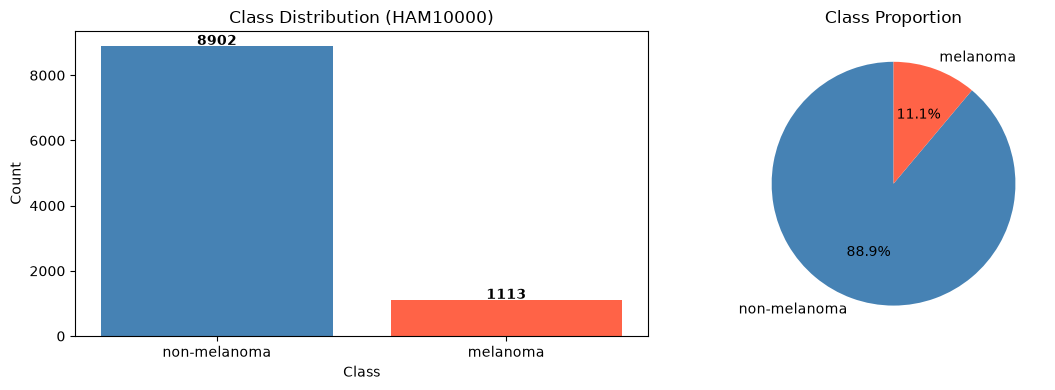


=== Detailed breakdown by dx ===
   dx   label_name  count
akiec non-melanoma    327
  bcc non-melanoma    514
  bkl non-melanoma   1099
   df non-melanoma    115
  mel     melanoma   1113
   nv non-melanoma   6705
 vasc non-melanoma    142


In [9]:
# ── Class distribution check (non-melanoma / melanoma) ────────────────────────
print("=== Class Distribution ===")
print(df['label_name'].value_counts())
print(f"\nMelanoma rate: {df['binary_label'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['label_name'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (HAM10000)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 30, str(cnt), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()

# Per-class detail
print("\n=== Detailed breakdown by dx ===")
print(df.groupby(['dx','label_name'])['stem'].count().reset_index(name='count').to_string(index=False))

## Train/val split (stratified on binary label)

In [10]:

from sklearn.model_selection import StratifiedGroupKFold

# Five folds provide an approximately 80/20 grouped split.
# Stratification is by diagnosis label, while grouping prevents any lesion_id
# from appearing in both training and validation sets.
splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

train_idx, val_idx = next(
    splitter.split(
        X=df,
        y=df["binary_label"],
        groups=df["lesion_id"],
    )
)

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
val_df = df.iloc[val_idx].copy().reset_index(drop=True)

train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
shared_lesions = train_lesions & val_lesions

assert not shared_lesions, (
    f"Lesion-level leakage detected: {len(shared_lesions)} shared lesion IDs"
)
assert len(train_df) + len(val_df) == len(df)
assert set(train_df["stem"]).isdisjoint(set(val_df["stem"]))

print(f"Train images: {len(train_df)} | Validation images: {len(val_df)}")
print(
    f"Train lesions: {train_df['lesion_id'].nunique()} | "
    f"Validation lesions: {val_df['lesion_id'].nunique()}"
)
print(f"Shared lesion IDs: {len(shared_lesions)}")

print("\nTrain distribution:")
print(train_df["label_name"].value_counts())
print("\nValidation distribution:")
print(val_df["label_name"].value_counts())

print(
    "\nMelanoma rates — "
    f"train: {train_df['binary_label'].mean():.3%}, "
    f"validation: {val_df['binary_label'].mean():.3%}"
)

# Save the exact partitions for reproducibility and later auditing.
split_dir = OUTPUT_DIR / "splits"
split_dir.mkdir(parents=True, exist_ok=True)

train_split_path = split_dir / "phase2_train_grouped_by_lesion.csv"
val_split_path = split_dir / "phase2_validation_grouped_by_lesion.csv"

train_df.to_csv(train_split_path, index=False)
val_df.to_csv(val_split_path, index=False)

print(f"Saved: {train_split_path}")
print(f"Saved: {val_split_path}")


Train images: 8012 | Validation images: 2003
Train lesions: 5976 | Validation lesions: 1494
Shared lesion IDs: 0

Train distribution:
label_name
non-melanoma    7122
melanoma         890
Name: count, dtype: int64

Validation distribution:
label_name
non-melanoma    1780
melanoma         223
Name: count, dtype: int64

Melanoma rates — train: 11.108%, validation: 11.133%
Saved: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/outputs/splits/phase2_train_grouped_by_lesion.csv
Saved: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/outputs/splits/phase2_validation_grouped_by_lesion.csv


## Transforms (resize only during validation, augmentation during training)

In [11]:
# Training: augment first, then resize and normalise
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # resize after augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Validation: resize only — no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

## Dataset class

In [12]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df      = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.img_dir / f"{row['stem']}.jpg"
        image    = Image.open(img_path).convert("RGB")
        label    = int(row['binary_label'])
        if self.transform:
            image = self.transform(image)
        return image, label

## DataLoaders with weighted sampler for class imbalance

In [13]:
train_ds = SkinLesionDataset(train_df, HAM_IMG_DIR, transform=train_transforms)
val_ds   = SkinLesionDataset(val_df,   HAM_IMG_DIR, transform=val_transforms)

# Weighted sampler so non-melanoma/melanoma are seen equally during training
class_counts   = train_df['binary_label'].value_counts().sort_index().values
sample_weights = [1.0 / class_counts[l] for l in train_df['binary_label']]
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 251 | Val batches: 63


## ResNet-50 model setup: frozen backbone, binary head, weighted BCE loss

In [14]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head for binary output
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 1)
)

model = model.to(DEVICE)

optimizer = optim.Adam(model.fc.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# ── Define class_counts here so it's self-contained ──────────────────────
class_counts = train_df['binary_label'].value_counts().sort_index().values

# Standard positive-class weighting for binary imbalance.
# No extra multiplier is used: pos_weight = non-melanoma_count / melanoma_count.
pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(model.fc)
print(f"Class counts (non-melanoma / melanoma): {class_counts}")
print(f"pos_weight: {pos_weight.item():.4f}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=2048, out_features=1, bias=True)
)
Class counts (non-melanoma / melanoma): [7122  890]
pos_weight: 8.0022
Trainable params: 2,049


## Training phase: unfreeze layer4 and classifier head

/tmp/ipykernel_1490/185908902.py:60: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 01/3 | Train loss: 1.0593  acc: 0.6578 | Val loss: 0.9536  acc: 0.6061
  ✓ Checkpoint saved (val_acc=0.6061)
Epoch 02/3 | Train loss: 0.6604  acc: 0.7839 | Val loss: 0.8792  acc: 0.7279
  ✓ Checkpoint saved (val_acc=0.7279)
Epoch 03/3 | Train loss: 0.4801  acc: 0.8571 | Val loss: 0.8813  acc: 0.7169


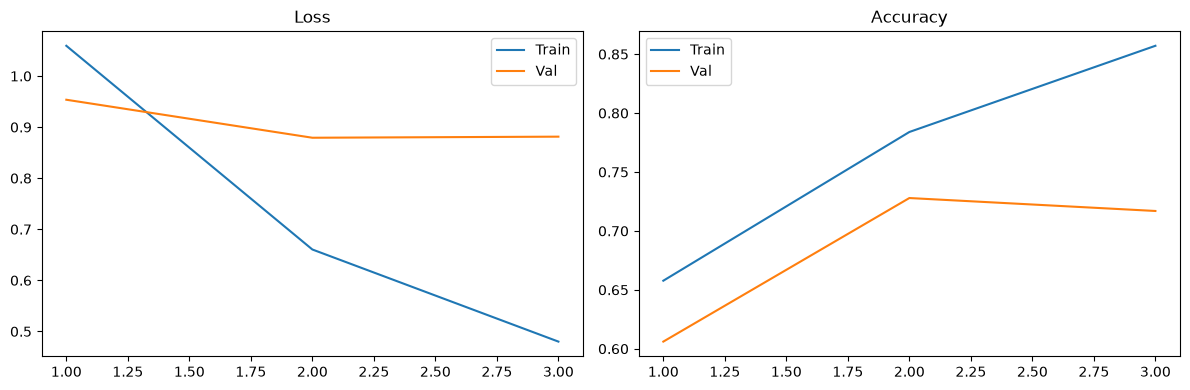


Optimal threshold: 0.85 | Best macro F1: 0.7119


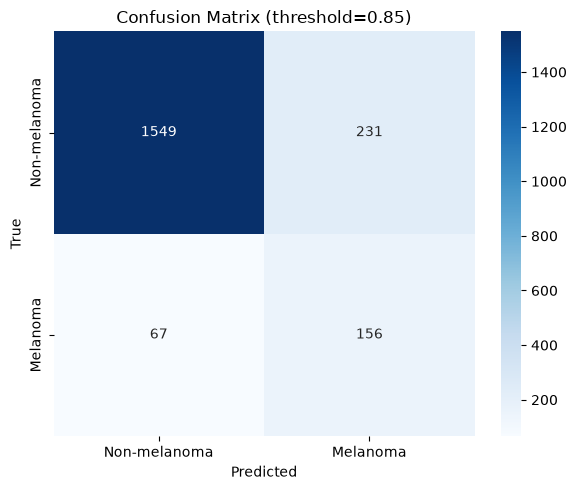

AUC:              0.8904
Macro F1:         0.7119
Threshold used:   0.85
              precision    recall  f1-score   support

Non-melanoma       0.96      0.87      0.91      1780
    Melanoma       0.40      0.70      0.51       223

    accuracy                           0.85      2003
   macro avg       0.68      0.78      0.71      2003
weighted avg       0.90      0.85      0.87      2003



In [15]:
# Unfreeze layer4 + classifier head for transfer learning
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

NUM_EPOCHS = 3  # initial transfer-learning phase

# ─────────────────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds       = (torch.sigmoid(outputs) >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += imgs.size(0)
        total_loss += loss.item() * imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            probs   = torch.sigmoid(outputs)
            preds   = (probs >= 0.5).long()
            correct    += (preds == labels.long()).sum().item()
            total      += imgs.size(0)
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.long().cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())
    return total_loss / total, correct / total, all_preds, all_labels, all_probs


# ── Training loop ─────────────────────────────────────────────────────────
history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
          f"Val loss: {vl_loss:.4f}  acc: {vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': vl_acc,
        }, CHECKPOINT_DIR / "best_resnet50_binary.pt")
        print(f"  ✓ Checkpoint saved (val_acc={vl_acc:.4f})")


# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep_range = range(1, NUM_EPOCHS + 1)
axes[0].plot(ep_range, history['train_loss'], label='Train')
axes[0].plot(ep_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(ep_range, history['train_acc'], label='Train')
axes[1].plot(ep_range, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_curves.png", dpi=150)
plt.show()


# ── Get val probabilities ─────────────────────────────────────────────────
_, _, preds, true_labels, probs = evaluate(model, val_loader, criterion, DEVICE)
probs = np.array(probs)


# ── Find optimal threshold via macro F1 ───────────────────────────────────
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = []
for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1      = f1_score(true_labels, preds_t, average='macro')
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)
print(f"\nOptimal threshold: {best_threshold:.2f} | Best macro F1: {best_f1:.4f}")

best_preds = (probs >= best_threshold).astype(int)


# ── Confusion matrix (with optimal threshold) ─────────────────────────────
cm = confusion_matrix(true_labels, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Non-melanoma', 'Melanoma'],
            yticklabels=['Non-melanoma', 'Melanoma'], cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title(f'Confusion Matrix (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150)
plt.show()


# ── Final metrics ─────────────────────────────────────────────────────────
auc = roc_auc_score(true_labels, probs)
print(f"AUC:              {auc:.4f}")
print(f"Macro F1:         {best_f1:.4f}")
print(f"Threshold used:   {best_threshold:.2f}")
print(classification_report(true_labels, best_preds, target_names=['Non-melanoma', 'Melanoma']))

## Fine-tuning phase

Fine-tuning with layer4 + fc unfrozen...
Trainable params: 14,966,785
FT Epoch 01/3 | Train loss: 0.3889  acc: 0.8843 | Val loss: 0.8401  acc: 0.8053
  ✓ Fine-tuned checkpoint saved (val_acc=0.8053)
FT Epoch 02/3 | Train loss: 0.3315  acc: 0.8995 | Val loss: 0.8651  acc: 0.8258
  ✓ Fine-tuned checkpoint saved (val_acc=0.8258)
FT Epoch 03/3 | Train loss: 0.2902  acc: 0.9207 | Val loss: 0.9236  acc: 0.8362
  ✓ Fine-tuned checkpoint saved (val_acc=0.8362)

Optimal threshold: 0.75
AUC:     0.8817
Macro F1:0.7344
              precision    recall  f1-score   support

Non-melanoma       0.95      0.91      0.93      1780
    Melanoma       0.47      0.62      0.54       223

    accuracy                           0.88      2003
   macro avg       0.71      0.77      0.73      2003
weighted avg       0.90      0.88      0.89      2003



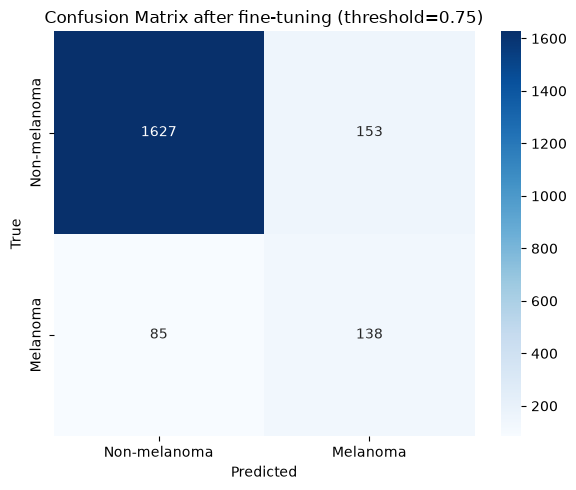

In [16]:
# ── Fine-tuning phase: 3 more epochs, layer4 + fc only (already unfrozen) ─
FINETUNE_EPOCHS = 3
LR_FINETUNE     = 1e-5  # lower LR to avoid destroying what was learned

# Lower LR for fine-tuning
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FINETUNE
)

print("Fine-tuning with layer4 + fc unfrozen...")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

for epoch in range(FINETUNE_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer_ft, criterion, DEVICE)
    vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"FT Epoch {epoch+1:02d}/{FINETUNE_EPOCHS} | "
          f"Train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
          f"Val loss: {vl_loss:.4f}  acc: {vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer_ft.state_dict(),
            'val_acc': vl_acc,
        }, CHECKPOINT_DIR / "best_resnet50_finetuned.pt")
        print(f"  ✓ Fine-tuned checkpoint saved (val_acc={vl_acc:.4f})")


# ── Re-evaluate with optimal threshold ───────────────────────────────────
_, _, preds, true_labels, probs = evaluate(model, val_loader, criterion, DEVICE)
probs = np.array(probs)

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = [f1_score(true_labels, (probs >= t).astype(int), average='macro') 
              for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_preds     = (probs >= best_threshold).astype(int)

print(f"\nOptimal threshold: {best_threshold:.2f}")
print(f"AUC:     {roc_auc_score(true_labels, probs):.4f}")
print(f"Macro F1:{max(f1_scores):.4f}")
print(classification_report(true_labels, best_preds, target_names=['Non-melanoma', 'Melanoma']))

cm = confusion_matrix(true_labels, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Non-melanoma', 'Melanoma'],
            yticklabels=['Non-melanoma', 'Melanoma'], cmap='Blues')
plt.title(f'Confusion Matrix after fine-tuning (threshold={best_threshold:.2f})')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_finetuned.png", dpi=150)
plt.show()

## Training curves

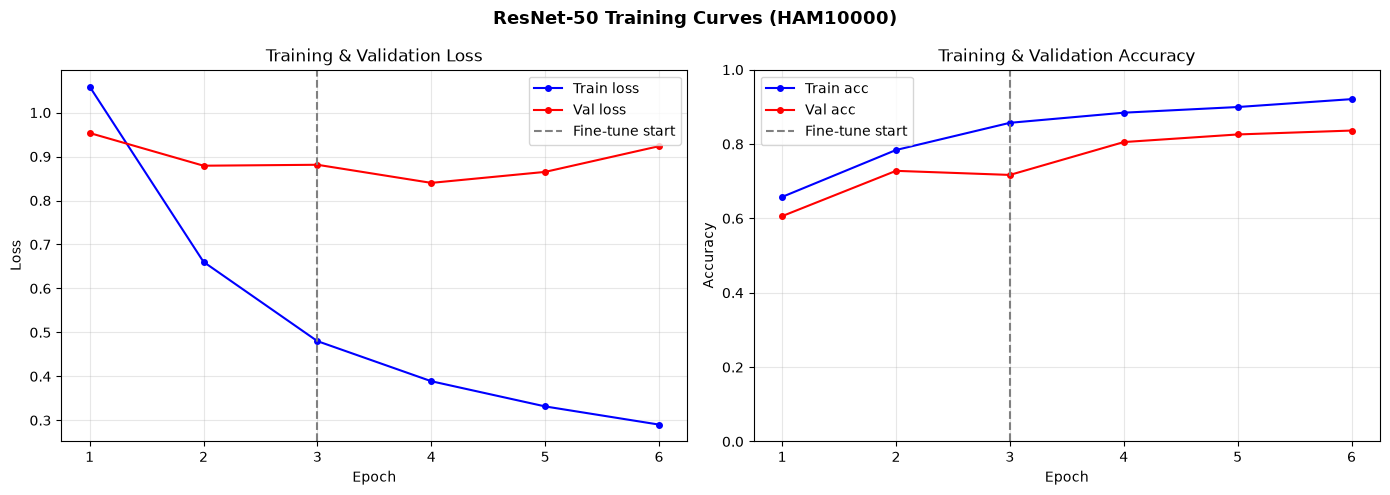

Best val accuracy: 0.8362


In [17]:
# ── Training curves (all epochs: baseline + fine-tune) ───────────────────
total_epochs = len(history['train_loss'])
ep_range = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep_range, history['train_loss'], 'b-o', label='Train loss', markersize=4)
axes[0].plot(ep_range, history['val_loss'],   'r-o', label='Val loss',   markersize=4)
if total_epochs > 3:
    axes[0].axvline(x=NUM_EPOCHS, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, history['train_acc'], 'b-o', label='Train acc', markersize=4)
axes[1].plot(ep_range, history['val_acc'],   'r-o', label='Val acc',   markersize=4)
if total_epochs > 3:
    axes[1].axvline(x=NUM_EPOCHS, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResNet-50 Training Curves (HAM10000)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'training_curves.png', dpi=150)
plt.show()
print(f"Best val accuracy: {best_val_acc:.4f}")

## Final Summary

In [18]:
# ── Final evaluation metrics ──────────────────────────────────────────────

auc_roc = roc_auc_score(true_labels, probs)

report = classification_report(
    true_labels,
    best_preds,
    target_names=["Non-melanoma", "Melanoma"],
    output_dict=True,
)

accuracy = report["accuracy"]
macro_precision = report["macro avg"]["precision"]
macro_recall = report["macro avg"]["recall"]
macro_f1 = report["macro avg"]["f1-score"]

melanoma_precision = report["Melanoma"]["precision"]
melanoma_recall = report["Melanoma"]["recall"]
melanoma_f1 = report["Melanoma"]["f1-score"]


# ── Final evaluation summary ─────────────────────────────────────────────

print("=" * 55)
print("  PHASE 2 — BASELINE ResNet-50 FINAL RESULTS")
print("=" * 55)
print(f"  Total epochs trained : {len(history['train_loss'])}")
print(f"  Best val accuracy    : {best_val_acc:.4f}")
print(f"  Accuracy at threshold: {accuracy:.4f}")
print(f"  AUC-ROC              : {auc_roc:.4f}")
print(f"  Optimal threshold    : {best_threshold:.2f}")
print(f"  Macro precision      : {macro_precision:.4f}")
print(f"  Macro recall         : {macro_recall:.4f}")
print(f"  Macro F1             : {macro_f1:.4f}")
print("=" * 55)

print(
    classification_report(
        true_labels,
        best_preds,
        target_names=["Non-melanoma", "Melanoma"],
    )
)


# ── List saved artefacts ──────────────────────────────────────────────────

print("\nSaved artefacts:")

for p in sorted(CHECKPOINT_DIR.glob("*.pt")):
    size_mb = p.stat().st_size / 1e6
    print(f"  {p.name}  ({size_mb:.1f} MB)")

print("  training_curves.png")
print("  confusion_matrix.png")
print("  confusion_matrix_finetuned.png")
print("  class_distribution.png")


# ── Save complete validation metrics ──────────────────────────────────────

metrics_summary = pd.DataFrame([{
    "phase": "phase2_resnet50",
    "dataset": "ham10000",
    "split": "validation",

    "accuracy": accuracy,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "auc_roc": auc_roc,

    "melanoma_precision": melanoma_precision,
    "melanoma_recall": melanoma_recall,
    "melanoma_f1": melanoma_f1,

    "best_threshold": float(best_threshold),
    "best_val_accuracy_training": float(best_val_acc),

    "split_method": "StratifiedGroupKFold_first_fold",
    "group_column": "lesion_id",
    "train_samples": int(len(train_df)),
    "val_samples": int(len(val_df)),
    "train_unique_lesions": int(train_df["lesion_id"].nunique()),
    "val_unique_lesions": int(val_df["lesion_id"].nunique()),
    "shared_lesion_ids": int(len(set(train_df["lesion_id"]) & set(val_df["lesion_id"]))),
    "pos_weight": float(pos_weight.item()),
}])

metrics_path = (
    METRICS_DIR
    / "phase2_resnet50_validation_metrics.csv"
)

metrics_summary.to_csv(
    metrics_path,
    index=False,
)

print(f"  {metrics_path}")


  PHASE 2 — BASELINE ResNet-50 FINAL RESULTS
  Total epochs trained : 6
  Best val accuracy    : 0.8362
  Accuracy at threshold: 0.8812
  AUC-ROC              : 0.8817
  Optimal threshold    : 0.75
  Macro precision      : 0.7123
  Macro recall         : 0.7664
  Macro F1             : 0.7344
              precision    recall  f1-score   support

Non-melanoma       0.95      0.91      0.93      1780
    Melanoma       0.47      0.62      0.54       223

    accuracy                           0.88      2003
   macro avg       0.71      0.77      0.73      2003
weighted avg       0.90      0.88      0.89      2003


Saved artefacts:
  best_resnet50_binary.pt  (214.1 MB)
  best_resnet50_finetuned.pt  (214.1 MB)
  training_curves.png
  confusion_matrix.png
  confusion_matrix_finetuned.png
  class_distribution.png
  /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/outputs/metrics/phase2_resnet50_validation_metrics.csv
